# Classificação Multiclasse com MLP no dataset Iris

Dataset: `iris.csv`
Alvo: `Species` (3 classes)

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from mlp import (
    MLP, Dense,
    ReLU, Softmax,
    CategoricalCrossEntropy,
    HeNormal, GlorotUniform,
    GradientDescent,
    accuracy_score, confusion_matrix,
    train_test_split, StandardScaler
)

print('Imports OK — project_root:', project_root)

Imports OK — project_root: c:\Users\gusta\Documents\Repositories\AM


## 1. Carregamento e pré-processamento dos dados

Nesta etapa, carregamos o conjunto de dados Iris, que possui 4 características (features) contínuas. 
Como estamos tratando de um problema de **classificação multiclasse**, a variável alvo categórica `Species` (composta por 3 classes) 
foi transformada utilizando a técnica de **One-Hot Encoding**. Isso é necessário pois a nossa rede neural terá 3 neurônios 
na camada de saída (um para cada classe), necessitando de um vetor de 3 posições para o cálculo da função de custo.

In [14]:
import csv

csv_path = os.path.join(project_root, 'data', 'iris.csv')

rows = []
with open(csv_path, newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append(row)

feature_cols = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
X = np.array([[float(r[c]) for c in feature_cols] for r in rows])

species_map = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
y_labels = np.array([species_map[r['Species']] for r in rows])

# One-Hot Encoding do alvo
num_classes = len(species_map)
y = np.zeros((len(y_labels), num_classes))
y[np.arange(len(y_labels)), y_labels] = 1

print(f'Shape X: {X.shape} | Shape y: {y.shape}')

Shape X: (150, 4) | Shape y: (150, 3)


## 2. Divisão Treino/Teste e Padronização

Os dados foram embaralhados aleatoriamente e divididos em 80% para treino e 20% para teste. 
Em seguida, aplicamos a **padronização** (Z-score normalization) nos dados utilizando a classe `StandardScaler`. 
Padronizar os dados de entrada é fundamental em redes neurais multicamadas para garantir que todas as características 
tenham a mesma escala, acelerando a convergência do algoritmo de *Gradient Descent* e evitando que a rede dê peso excessivo 
a variáveis com magnitudes maiores.

In [15]:
# Embaralha e divide com split manual
rng = np.random.default_rng(42)
idx = rng.permutation(len(X))
X, y = X[idx], y[idx]
y_labels = y_labels[idx]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'Treino: {X_train.shape} | Teste: {X_test.shape}')

Treino: (120, 4) | Teste: (30, 4)


## 3. Arquitetura do Modelo

Nesta seção utilizamos a API da nossa biblioteca para instanciar e compilar a MLP. A arquitetura escolhida possui:
- **Camada de Entrada**: 4 neurônios implícitos (referente às 4 features do Iris).
- **1 Camada Oculta**: 16 neurônios com função de ativação **ReLU** (padrão em camadas ocultas para evitar o desaparecimento do gradiente) 
e inicialização de pesos **HeNormal** (ideal para ativações baseadas em ReLU).
- **Camada de Saída**: 3 neurônios (referente às 3 classes) com função de ativação **Softmax** (ideal para classificação multiclasse, 
pois converte as saídas em uma distribuição de probabilidade) e inicialização **Glorot/Xavier Uniform**.

Ao compilar, adotamos a função de perda **Categorical Cross-Entropy**, que é a métrica padrão a ser pareada com a ativação Softmax, 
e o otimizador clássico de **Gradient Descent**.

In [16]:
model = MLP()
model.add(Dense(16, activation=ReLU(), initializer=HeNormal(seed=42)))
model.add(Dense(3, activation=Softmax(), initializer=GlorotUniform(seed=0)))

model.compile(
    loss=CategoricalCrossEntropy(),
    optimizer=GradientDescent(learning_rate=0.05),
    metric='accuracy'
)
print('Modelo: 4 → 16(ReLU) → 3(Softmax)')

Modelo: 4 → 16(ReLU) → 3(Softmax)


## 4. Treinamento

O treinamento foi realizado utilizando **mini-batches** de tamanho 16 durante 150 **épocas**. 
O uso de mini-batches fornece um bom equilíbrio entre estabilidade e velocidade na atualização dos pesos. 
O dataset também é embaralhado a cada época (`shuffle=True`) para evitar que a rede decore a ordem das amostras.

In [17]:
history = model.fit(
    X_train_s, y_train,
    epochs=150,
    batch_size=16,
    shuffle=True,
    verbose=True,
    validation_data=(X_test_s, y_test)
)

epoch    0  loss 1.0583  acc 0.4583  val_loss 0.9447  val_acc 0.4667
epoch    7  loss 0.3585  acc 0.8667  val_loss 0.3780  val_acc 0.8667
epoch   14  loss 0.2794  acc 0.9167  val_loss 0.3216  val_acc 0.9000
epoch   21  loss 0.2302  acc 0.9250  val_loss 0.2727  val_acc 0.9333
epoch   28  loss 0.1928  acc 0.9500  val_loss 0.2307  val_acc 0.9333
epoch   35  loss 0.1642  acc 0.9583  val_loss 0.2033  val_acc 0.9333
epoch   42  loss 0.1423  acc 0.9583  val_loss 0.1793  val_acc 0.9333
epoch   49  loss 0.1258  acc 0.9583  val_loss 0.1575  val_acc 0.9333
epoch   56  loss 0.1126  acc 0.9583  val_loss 0.1454  val_acc 0.9333
epoch   63  loss 0.1022  acc 0.9667  val_loss 0.1365  val_acc 0.9333
epoch   70  loss 0.0942  acc 0.9667  val_loss 0.1292  val_acc 0.9333
epoch   77  loss 0.0875  acc 0.9750  val_loss 0.1208  val_acc 0.9667
epoch   84  loss 0.0821  acc 0.9667  val_loss 0.1179  val_acc 0.9333
epoch   91  loss 0.0777  acc 0.9750  val_loss 0.1137  val_acc 0.9333
epoch   98  loss 0.0738  acc 0.975

## 5. Curvas de Loss e Acurácia

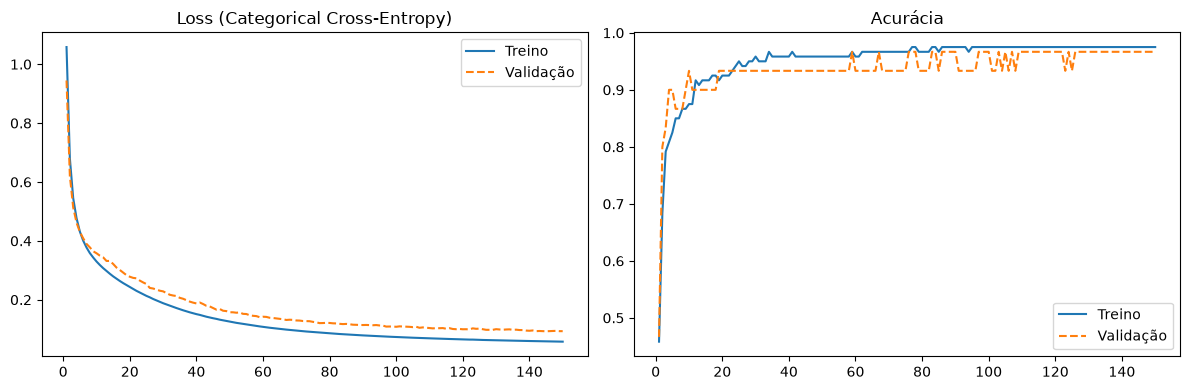

In [18]:
%matplotlib inline

epochs_range = range(1, len(history['loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epochs_range, history['loss'], label='Treino')
ax1.plot(epochs_range, history['val_loss'], label='Validação', linestyle='--')
ax1.set_title('Loss (Categorical Cross-Entropy)')
ax1.legend()

ax2.plot(epochs_range, history['accuracy'], label='Treino')
ax2.plot(epochs_range, history['val_accuracy'], label='Validação', linestyle='--')
ax2.set_title('Acurácia')
ax2.legend()

plt.tight_layout()
plt.show()

## 6. Avaliação Final e Matriz de Confusão

In [19]:
loss_val, acc = model.evaluate(X_test_s, y_test)
print(f'Loss Teste: {loss_val:.4f} | Acurácia Teste: {acc:.4f}')

y_pred_proba = model.predict_proba(X_test_s)
y_pred_classes = np.argmax(y_pred_proba, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_test_classes, y_pred_classes)
print('\nMatriz de Confusão:')
print(cm)

Loss Teste: 0.0932 | Acurácia Teste: 0.9667

Matriz de Confusão:
[[11  0  0]
 [ 0  6  1]
 [ 0  0 12]]


## 7. Análise Crítica dos Resultados

Os resultados obtidos pelo modelo treinado a partir do zero foram excelentes. A rede neural obteve uma **acurácia de 96,67%** no conjunto de testes não visto, generalizando muito bem os padrões das flores. Observando as curvas de Loss e Acurácia na Seção 5, notamos que a perda de validação (*val_loss*) acompanhou a queda contínua da perda de treino, sem divergir para cima, o que indica que **não houve overfitting** acentuado durante as 150 épocas de treinamento.

**Avaliação da Matriz de Confusão:**
Analisando a matriz gerada sobre as 30 amostras de teste, identificamos que o modelo apresentou **apenas 1 erro**:
* A rede classificou corretamente todas as amostras de **Setosa** e **Virginica**.
* Ocorreu apenas um falso negativo para a classe **Versicolor**, onde uma amostra dessa espécie acabou sendo incorretamente classificada pela rede como **Virginica**.

Esse comportamento é extremamente coerente com a distribuição original do dataset *Iris*. Sabe-se na literatura que a classe *Setosa* é linearmente separável em relação às demais, o que justifica os 100% de acerto. Por outro lado, as métricas das características (*features*) das espécies *Versicolor* e *Virginica* possuem certo nível de sobreposição no espaço vetorial, tornando comum que modelos de aprendizado de máquina tenham alguma dificuldade residual ao traçar o limite de decisão (*decision boundary*) exato entre as duas.

De forma geral, a nossa biblioteca *MLP* cumpriu com êxito o objetivo, convergindo adequadamente sob o algoritmo de *Gradient Descent* e alcançando alta precisão numa tarefa de classificação multiclasse típica.